# DYNAP-SE1 Excitatory/Inhibitory Network Experiment

This notebook builds a four-population excitatory/inhibitory network on a DYNAP-SE1 device, programs FPGA spike generators, records spikes, and plots the resulting network activity.

**Notebook flow**
1. Import packages and connect to the DYNAP-SE1 board.
2. Define network connection probabilities.
3. Build the excitatory and inhibitory populations.
4. Load chip/core parameters.
5. Program FPGA spike generators.
6. Run the experiment and collect spikes.
7. Plot activity and optionally save/reset parameters.


In [1]:
# =============================================================================
# 1. Imports and setup
# =============================================================================
import os
import subprocess

os.environ["LIBGL_ALWAYS_INDIRECT"] = "1"

import sys
import time
import importlib

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image

# Project-specific utilities. The parent directory contains helper modules.
sys.path.append('..')

import samna
import samna.dynapse1 as dyn1
import dynapse1utils as ut
import params

from netgen import Neuron, NetworkGenerator
from params import set_params


In [2]:
# =============================================================================
# 2. Connect to the DYNAP-SE1 board
# =============================================================================

# Open the DYNAP-SE1 board and retrieve a Dynapse1Model instance.
#
# The specific-device utility is used here because remote setups such as Zemo
# may expose more than one attached board. Change `device_id` if a different
# board should be selected.
#model, _ = ut.open_specific_device_in_sequence(device_id=1)

# alternative:
model, gui_process = ut.open_dynapse1(gui=True)

# =============================================================================
# 2. Connect to the DYNAP-SE1 board
# =============================================================================

# Open the DYNAP-SE1 board and retrieve a Dynapse1Model instance.
#
# The specific-device utility is used here because remote setups such as Zemo
# may expose more than one attached board. Change `device_id` if a different
# board should be selected.
#model, _ = ut.open_specific_device_in_sequence(device_id=1)

# alternative:
#model, _ = ut.open_dynapse1(gui=False, select_device=True)

# Get the low-level DYNAP-SE1 API from the model.
api = model.get_dynapse1_api()

# Optional oscilloscope/monitor target.
MONITOR_CHIP_ID = 0
MONITOR_NEURON_ID = 10
api.monitor_neuron(MONITOR_CHIP_ID, MONITOR_NEURON_ID)

CHIP_ID = 0
CORE_ID = 0
CORE_CAPACITY = 256


[0]:  Bus 3 Device 2 Dynapse1DevKit serial_number 00000033
0 Dynapse1Wrapper created! libcaer init...
Clearing chip 0... DONE.
Clearing chip 1... DONE.
Clearing chip 2... DONE.
Clearing chip 3... DONE.
Visualizer start command:  /home/mathilda/miniconda3/envs/dynapse1/bin/python -c "import samna, samnagui; samnagui.runVisualizer(0.75, 0.75,         'tcp://0.0.0.0:33335', 'tcp://0.0.0.0:33336', 3)"
GUI receiving port: tcp://0.0.0.0:62556
GUI node ID: 3
Selected device: 00000033
Sender port: tcp://0.0.0.0:33336
Receiver port: tcp://0.0.0.0:33335
Opened device name: Dynapse1DevKit
SamnaNode ID: 1
PythonNode ID: 2


Traceback (most recent call last):
  File "<string>", line 1, in <module>
RuntimeError: glfwCreateWindow(...) failed! Error code: 65545 description: GLX: Failed to find a suitable GLXFBConfig



In [3]:
api = model.get_dynapse1_api()

CHIP_ID = 0
E_CORE_ID =0
I_CORE_ID = 2
CORE_CAPACITY = 256

In [4]:
### OPEN VIZUALIZER IN TERMINAL BASH ###

# LD_PRELOAD=/usr/lib/x86_64-linux-gnu/libstdc++.so.6 /home/andreas/miniconda3/envs/dynapse1/bin/python -c "import samna, samnagui; samnagui.runVisualizer(0.75, 0.75, 'tcp://0.0.0.0:33335', 'tcp://0.0.0.0:33336', 3)"

In [5]:
from live_gui.sliderGui import run_threaded_gui

run_threaded_gui(model)

#gui = sliderGui(model)

/home/mathilda/Uni/SS26/NI/dynap-se1/project_/../live_gui/linear_fine_coarse_bias_map.npy


In [22]:
HUN = True
BASIC_PARAMS = False
EX_INDIVIDUAL_PARAMS = False
IN_INDIVIDUAL_PARAMS = False
PERFECT = True
REFERENCE = True
MATCH_TO = 3
PARAMS_SAVE = False

In [23]:
# =============================================================================
# 3. Load neuron and synapse parameters
# =============================================================================
# Option B: load parameters from a text file/profile.
# The profile name below should match the parameter file expected by the helper.
if HUN == True:
    ut.set_parameters_in_txt_file(model, 'hun')
    time.sleep(2)  # Short delay to ensure parameters are set before proceeding.


# Option A: use the parameter-setting helper from params.py.
# Uncomment if this is the preferred parameter source.
if BASIC_PARAMS == True:
    set_params(model)


if PERFECT == True:
    ut.set_parameters_in_txt_file(model, 'subthreshold params')


In [36]:
# =============================================================================
# 4. Network connection probabilities
# =============================================================================

# Probability of excitatory-to-excitatory recurrent connections.
p_E_E = 0.9

# Probability of excitatory-to-inhibitory feedforward connections.
p_E_I = 0.5

# Probability of inhibitory-to-excitatory feedback/cross-population connections.
p_I_E = 0.7

# Probability of inhibitory-to-inhibitory recurrent connections.
p_I_I = 0.2

# Probability of input channel to excitatory connections.
p_C_E = 1.0

# Probability of reference to excitatory connections.
if REFERENCE == True:    
    p_R_E = 1.0
else:    p_R_E = 0.0

In [37]:
if PARAMS_SAVE == True:
    ut.save_parameters2txt_file(model.get_configuration(), 'trying_to_save_params')

In [38]:
# -------------------------------------------------------------------------
# Population definitions (blob/square placement on 16x16 core)
# Compact square "blobs" per population — no avoids
# -------------------------------------------------------------------------
import math
# =============================================================================
# 5. Build and apply the E/I network configuration
# =============================================================================

# Reload parameter helper module so notebook edits are picked up without
# restarting the kernel.
importlib.reload(params)

serial_number = ut.get_serial_number()
print("Serial number:", serial_number)

# Create a fresh network generator.
net_gen = NetworkGenerator()
net_gen.clear_network()

# -----------------------------------------------------------------------------
# Spike generators
# -----------------------------------------------------------------------------
# Five virtual neurons are used as FPGA spike-generator sources.
# The first four drive the four excitatory populations. The fifth is reserved
# as a reference generator in the FPGA programming cell.

spikegen_ids = [
    (0, 1, 15),
    (0, 1, 16),
    (0, 1, 17),
    (0, 1, 18),
    (0, 1, 19),
]
spikegens = [Neuron(chip, core, neuron, True) for chip, core, neuron in spikegen_ids]

# population sizes (keep your existing values)
N_EXC_PER_POP = 16
N_INH_PER_POP = 16
N_POPULATIONS = 4

# core/grid parameters
GRID_SIDE = 16  # 16x16 neurons per core

def pos_to_id(x, y, grid=GRID_SIDE):
    return int(y) * grid + int(x)

def id_to_pos(nid, grid=GRID_SIDE):
    return (nid % grid, nid // grid)

def tile_center(pop_index, n_pops, grid=GRID_SIDE):
    tiles = int(math.ceil(math.sqrt(max(1, n_pops))))
    tx = pop_index % tiles
    ty = pop_index // tiles
    tile_w = grid / tiles
    cx = int(round(tx * tile_w + tile_w / 2 - 0.5))
    cy = int(round(ty * tile_w + tile_w / 2 - 0.5))
    cx = max(0, min(grid-1, cx))
    cy = max(0, min(grid-1, cy))
    return cx, cy

def square_blob_ids(center, n_neurons, grid=GRID_SIDE):
    cx, cy = center
    side = int(math.ceil(math.sqrt(n_neurons)))
    x0 = cx - side // 2
    y0 = cy - side // 2
    candidates = []
    for y in range(y0, y0 + side):
        for x in range(x0, x0 + side):
            if 0 <= x < grid and 0 <= y < grid:
                candidates.append((x, y))
    picked = []
    used = set()
    for x, y in candidates:
        picked.append((x, y)); used.add((x,y))
        if len(picked) >= n_neurons:
            break
    if len(picked) < n_neurons:
        all_cells = [(x, y, math.hypot(x-cx, y-cy)) for y in range(grid) for x in range(grid)]
        all_cells.sort(key=lambda t: (t[2], t[1], t[0]))
        for x, y, _ in all_cells:
            if (x,y) in used:
                continue
            picked.append((x,y)); used.add((x,y))
            if len(picked) >= n_neurons:
                break
    return [pos_to_id(x,y,grid) for x,y in picked[:n_neurons]]

def make_square_populations(chip_id, core_id, n_pops, per_pop, grid=GRID_SIDE):
    pops = []
    for pidx in range(n_pops):
        center = tile_center(pidx, n_pops, grid)
        ids = square_blob_ids(center, per_pop, grid=grid)
        pops.append([(chip_id, core_id, int(nid)) for nid in ids])
    return pops

# Create populations (replaces exc_neuron_ids / inh_neuron_ids construction)
exc_neuron_ids = make_square_populations(CHIP_ID, E_CORE_ID, N_POPULATIONS, N_EXC_PER_POP)
inh_neuron_ids = make_square_populations(CHIP_ID, I_CORE_ID, N_POPULATIONS, N_INH_PER_POP)

# Convert to Neuron objects (keep original naming)
exc_neurons = [[Neuron(chip, core, neuron) for chip, core, neuron in population] for population in exc_neuron_ids]
inh_neurons = [[Neuron(chip, core, neuron) for chip, core, neuron in population] for population in inh_neuron_ids]

# Optional: print and quick visual check (uncomment to view)
print("Excitatory neuron ids:", exc_neuron_ids)
print("Inhibitory neuron ids:", inh_neuron_ids)


# Keep the original variable names for compatibility with later notebook cells.
#exc_neuron_ids_1, exc_neuron_ids_2, exc_neuron_ids_3, exc_neuron_ids_4 = exc_neuron_ids
#exc_neurons_1, exc_neurons_2, exc_neurons_3, exc_neurons_4 = exc_neurons
#inh_neuron_ids_1, inh_neuron_ids_2, inh_neuron_ids_3, inh_neuron_ids_4 = inh_neuron_ids
#inh_neurons_1, inh_neurons_2, inh_neurons_3, inh_neurons_4 = inh_neurons

# -----------------------------------------------------------------------------
# Excitatory populations: input drive + recurrent E->E connectivity
# -----------------------------------------------------------------------------
for pop_index, population in enumerate(exc_neurons):
    input_generator = spikegens[pop_index]

    for pre_index, pre_neuron in enumerate(population):
        # Connect the population-specific FPGA spike generator to each
        # excitatory neuron using slow excitatory AMPA synapses.
        if np.random.uniform() < p_C_E:
            net_gen.add_connection(input_generator, pre_neuron, dyn1.Dynapse1SynType.AMPA)

        # Add recurrent E->E connections within the same population.
        for post_index, post_neuron in enumerate(population):
            if pre_index != post_index and np.random.uniform() < p_E_E:
                net_gen.add_connection(pre_neuron, post_neuron, dyn1.Dynapse1SynType.NMDA)

# -----------------------------------------------------------------------------
# Inhibitory populations: recurrent I->I connectivity
# -----------------------------------------------------------------------------
for population in inh_neurons:
    for pre_index, pre_neuron in enumerate(population):
        for post_index, post_neuron in enumerate(population):
            if pre_index != post_index and np.random.uniform() < p_I_I:
                net_gen.add_connection(pre_neuron, post_neuron, dyn1.Dynapse1SynType.GABA_A)

# -----------------------------------------------------------------------------
# Excitatory-to-inhibitory connections within matching populations
# -----------------------------------------------------------------------------
for pop_index in range(N_POPULATIONS):
    for exc_neuron in exc_neurons[pop_index]:
        for inh_neuron in inh_neurons[pop_index]:
            if np.random.uniform() < p_E_I:
                net_gen.add_connection(exc_neuron, inh_neuron, dyn1.Dynapse1SynType.AMPA)

# -----------------------------------------------------------------------------
# Inhibitory-to-excitatory cross-population connections
# -----------------------------------------------------------------------------
# Inhibition from population i targets excitatory neurons in all other
# populations h != i using slow inhibitory GABA_B synapses.
for inh_pop_index in range(N_POPULATIONS):
    for exc_pop_index in range(N_POPULATIONS):
        if inh_pop_index == exc_pop_index:
            continue

        for inh_neuron in inh_neurons[inh_pop_index]:
            for exc_neuron in exc_neurons[exc_pop_index]:
                if np.random.uniform() < p_I_E:
                    net_gen.add_connection(inh_neuron, exc_neuron, dyn1.Dynapse1SynType.GABA_B)

# -----------------------------------------------------------------------------
# Reference generator -> all excitatory populations
# -----------------------------------------------------------------------------
# Connect the last spike generator (reference) to every excitatory neuron
if len(spikegens) > N_POPULATIONS:
    ref_gen = spikegens[N_POPULATIONS]
    for population in exc_neurons:
        for neuron in population:
            if np.random.uniform() < p_R_E:
                net_gen.add_connection(ref_gen, neuron, dyn1.Dynapse1SynType.NMDA)
else:
    print('Warning: reference spike generator (spikegens[N_POPULATIONS]) not available; no reference connections added')

# Review the generated network before applying it.
print(net_gen.network)

# Convert the generated network into a DYNAP-SE1 configuration and apply it.
new_config = net_gen.make_dynapse1_configuration()
model.apply_configuration(new_config)



Serial number: 00000033
Excitatory neuron ids: [[(0, 0, 34), (0, 0, 35), (0, 0, 36), (0, 0, 37), (0, 0, 50), (0, 0, 51), (0, 0, 52), (0, 0, 53), (0, 0, 66), (0, 0, 67), (0, 0, 68), (0, 0, 69), (0, 0, 82), (0, 0, 83), (0, 0, 84), (0, 0, 85)], [(0, 0, 42), (0, 0, 43), (0, 0, 44), (0, 0, 45), (0, 0, 58), (0, 0, 59), (0, 0, 60), (0, 0, 61), (0, 0, 74), (0, 0, 75), (0, 0, 76), (0, 0, 77), (0, 0, 90), (0, 0, 91), (0, 0, 92), (0, 0, 93)], [(0, 0, 162), (0, 0, 163), (0, 0, 164), (0, 0, 165), (0, 0, 178), (0, 0, 179), (0, 0, 180), (0, 0, 181), (0, 0, 194), (0, 0, 195), (0, 0, 196), (0, 0, 197), (0, 0, 210), (0, 0, 211), (0, 0, 212), (0, 0, 213)], [(0, 0, 170), (0, 0, 171), (0, 0, 172), (0, 0, 173), (0, 0, 186), (0, 0, 187), (0, 0, 188), (0, 0, 189), (0, 0, 202), (0, 0, 203), (0, 0, 204), (0, 0, 205), (0, 0, 218), (0, 0, 219), (0, 0, 220), (0, 0, 221)]]
Inhibitory neuron ids: [[(0, 2, 34), (0, 2, 35), (0, 2, 36), (0, 2, 37), (0, 2, 50), (0, 2, 51), (0, 2, 52), (0, 2, 53), (0, 2, 66), (0, 2, 67),

In [39]:
ut.set_parameters_in_txt_file(model, 'subthreshold params')

In [40]:
# =============================================================================
# 6. Program FPGA spike generators
# =============================================================================

# The first four spike generators drive the four excitatory populations.
fpga_ids = ut.get_global_id_list(spikegen_ids[:N_POPULATIONS])
print("FPGA generator IDs:", fpga_ids)

# Stimulus duration, in seconds.
duration = 20.0

# The fifth spike generator is used as a reference generator.
ref_fpga_id = ut.get_global_id_list(spikegen_ids)[N_POPULATIONS]
print("Reference generator FPGA ID:", ref_fpga_id)
fpga = model.get_fpga_spike_gen()

# One pattern per channel: (start_s, end_s, rate_hz)
patterns = {
    0: [(0, 4, 35), (4, 8, 21), (8, 10, 69)],
    1: [(0, 5, 10), (5, 10, 80)],
    2: [(0, 2, 62), (2, 6, 65), (6, 9, 33), (9, 10, 16)],
    3: [(0, 1, 29), (1, 4, 33), (4, 5, 20), (5, 10, 43)],
}

# Build spike lists
all_times = []
all_indices = []
all_targets = []
channel_times = {}

# Schedule spikes for each channel according to its pattern segments.
for ch_idx, segments in patterns.items():
    ids = fpga_ids[ch_idx]
    times = []
    for start_s, end_s, rate_hz in segments:
        if end_s <= start_s or rate_hz <= 0:
            continue
        n_spikes = int(np.ceil(rate_hz * (end_s - start_s)))
        spike_times = np.linspace(start_s, end_s, n_spikes, endpoint=False).tolist()
        times.extend(spike_times)
    channel_times[ch_idx] = times
    all_times.extend(times)
    all_indices.extend([ids] * len(times))
    all_targets.extend([E_CORE_ID] * len(times))


# Make reference identical to selected channel
ref_times = channel_times.get(MATCH_TO, [])
all_times.extend(ref_times)
all_indices.extend([ref_fpga_id] * len(ref_times))
all_targets.extend([E_CORE_ID] * len(ref_times))

# Sort once and program FPGA
order = np.argsort(all_times)
all_times = np.array(all_times)[order].tolist()
all_indices = np.array(all_indices)[order].tolist()
all_targets = np.array(all_targets)[order].tolist()

# For plotting later
input_spike_times = {f"Ch{idx+1}": times for idx, times in channel_times.items()}
input_spike_times["Ref"] = ref_times
correlated_channel = MATCH_TO

isi_base = 900
repeat_mode = True  

ut.set_fpga_spike_gen(fpga, all_times, all_indices, all_targets, isi_base, repeat_mode)

FPGA generator IDs: [271, 272, 273, 274]
Reference generator FPGA ID: 275
VariableIsiMode already 1
RepeatMode already 1


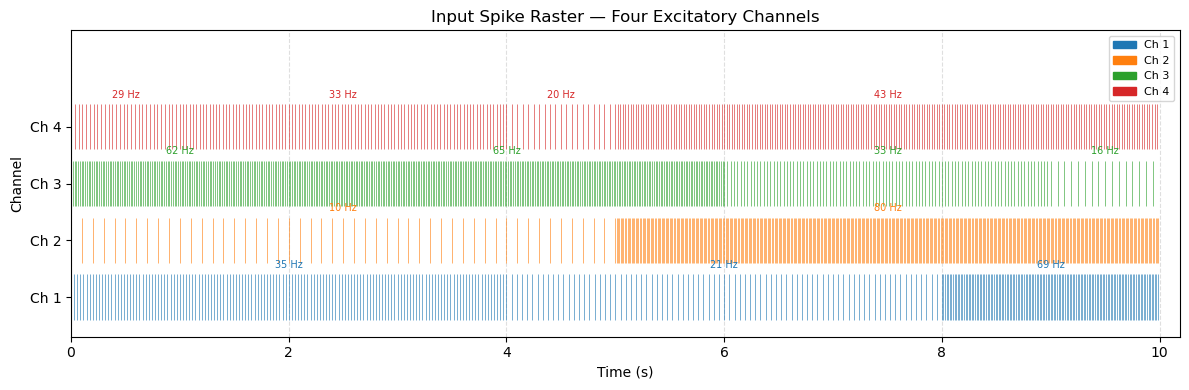

In [41]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(12, 4))

channel_labels = [f"Ch {i+1}" for i in range(N_POPULATIONS)]
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

for ch_idx, (label, color) in enumerate(zip(channel_labels, colors)):
    times = channel_times[ch_idx]
    ax.vlines(
        times,
        ymin=ch_idx + 0.6,
        ymax=ch_idx + 1.4,
        color=color,
        linewidth=0.6,
        alpha=0.7,
        label=label,
    )

    # Annotate rate segments as shaded bands
    for start_s, end_s, rate_hz in patterns[ch_idx]:
        ax.text(
            (start_s + end_s) / 2,
            ch_idx + 1.48,
            f"{rate_hz} Hz",
            ha="center", va="bottom",
            fontsize=7, color=color,
        )

ax.set_yticks(range(1, N_POPULATIONS + 1))
ax.set_yticklabels(channel_labels)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Channel")
ax.set_title("Input Spike Raster — Four Excitatory Channels")
ax.set_xlim(0, max(max(t) for t in channel_times.values()) * 1.02)
ax.set_ylim(0.3, N_POPULATIONS + 1.7)
ax.grid(axis="x", linestyle="--", alpha=0.4)

patches = [mpatches.Patch(color=c, label=l) for c, l in zip(colors, channel_labels)]
ax.legend(handles=patches, loc="upper right", fontsize=8)

plt.tight_layout()
plt.savefig("raster_input_patterns.png", dpi=150)
plt.show()

In [42]:
# =============================================================================
# 7. Run the network and collect events
# =============================================================================

# Continue recording after the stimulus stops to capture post-stimulus activity.
duration_post_stim = 10.0

# Total recorded duration.
D = duration + duration_post_stim

# Total population sizes used for normalization during plotting.
NI = sum(len(population) for population in inh_neuron_ids)
NE = sum(len(population) for population in exc_neuron_ids)


# Flatten all populations into one monitor list.
monitored_neurons = [
    neuron
    for population in exc_neuron_ids
    for neuron in population
] + [
    neuron
    for population in inh_neuron_ids
    for neuron in population
]


# Create and start a selective monitoring graph.
graph, filter_node, sink_node = ut.create_neuron_select_graph(model, monitored_neurons)
graph.start()

print("Monitored neurons:", monitored_neurons)
filter_node.set_neurons(monitored_neurons)

# Clear any stale events before starting the trial.
sink_node.get_events()
api.reset_timestamp()

# Start stimulus, wait for the stimulus duration, then stop the FPGA.
fpga.start()
time.sleep(duration)
fpga.stop()

# Keep recording for post-stimulus activity.
time.sleep(duration_post_stim)
graph.stop()

# Retrieve recorded events from the sink node.
events = sink_node.get_events()
print(len(events), "events recorded.")

# Convert neuron ID tuples into chip-local neuron IDs for classification.
e_neuron_chip_ids = [nid[2] for population in exc_neuron_ids for nid in population if nid[0] == 0 and nid[1] == 0]
i_neuron_chip_ids = [nid[2] for population in inh_neuron_ids for nid in population if nid[0] == 0 and nid[1] == 0]

# Extract event times for both relevant cores
spike_t = []
spike_core = []
spike_id = []

for evt in events:
    if evt.chip_id == 0 and evt.core_id in (E_CORE_ID, I_CORE_ID):
        spike_t.append(evt.timestamp * 1e-6)
        spike_core.append(evt.core_id)
        spike_id.append(evt.neuron_id)

spike_t = np.array(spike_t)
spike_core = np.array(spike_core)
spike_id = np.array(spike_id)

# Since E neurons are on core 0 and I neurons on core 2 in this notebook
is_e_spike = spike_core == E_CORE_ID
is_i_spike = spike_core == I_CORE_ID

e_spike_t = spike_t[is_e_spike]
e_spike_id = spike_id[is_e_spike] + E_CORE_ID * 256
i_spike_t = spike_t[is_i_spike]
i_spike_id = spike_id[is_i_spike] + I_CORE_ID * 256

# -----------------------------------------------------------------------------
# Compute smoothed population-rate traces
# -----------------------------------------------------------------------------
fs = 200  # Sampling frequency for binned spike trains, in Hz.
n_bins = int(D * fs)

# Rows: 0 = excitatory population, 1 = inhibitory population
binPOP = np.zeros((2, n_bins))

for t in e_spike_t:
    if t < D:
        binPOP[0, int(t * fs)] = 1

for t in i_spike_t:
    if t < D:
        binPOP[1, int(t * fs)] = 1

# Smooth binned spikes with a Gaussian-like kernel.
sigma = 0.01
x = np.arange(int(-0.2 * fs), int(0.2 * fs)) / fs
gauss = np.exp(-(x ** 2) / sigma)

binPOP[0] = np.convolve(binPOP[0], gauss, 'same')
binPOP[1] = np.convolve(binPOP[1], gauss, 'same')


Monitored neurons: [(0, 0, 34), (0, 0, 35), (0, 0, 36), (0, 0, 37), (0, 0, 50), (0, 0, 51), (0, 0, 52), (0, 0, 53), (0, 0, 66), (0, 0, 67), (0, 0, 68), (0, 0, 69), (0, 0, 82), (0, 0, 83), (0, 0, 84), (0, 0, 85), (0, 0, 42), (0, 0, 43), (0, 0, 44), (0, 0, 45), (0, 0, 58), (0, 0, 59), (0, 0, 60), (0, 0, 61), (0, 0, 74), (0, 0, 75), (0, 0, 76), (0, 0, 77), (0, 0, 90), (0, 0, 91), (0, 0, 92), (0, 0, 93), (0, 0, 162), (0, 0, 163), (0, 0, 164), (0, 0, 165), (0, 0, 178), (0, 0, 179), (0, 0, 180), (0, 0, 181), (0, 0, 194), (0, 0, 195), (0, 0, 196), (0, 0, 197), (0, 0, 210), (0, 0, 211), (0, 0, 212), (0, 0, 213), (0, 0, 170), (0, 0, 171), (0, 0, 172), (0, 0, 173), (0, 0, 186), (0, 0, 187), (0, 0, 188), (0, 0, 189), (0, 0, 202), (0, 0, 203), (0, 0, 204), (0, 0, 205), (0, 0, 218), (0, 0, 219), (0, 0, 220), (0, 0, 221), (0, 2, 34), (0, 2, 35), (0, 2, 36), (0, 2, 37), (0, 2, 50), (0, 2, 51), (0, 2, 52), (0, 2, 53), (0, 2, 66), (0, 2, 67), (0, 2, 68), (0, 2, 69), (0, 2, 82), (0, 2, 83), (0, 2, 84), 

In [43]:
from collections import Counter, defaultdict

# count stimulus-window spikes per unit (chip,core,neuron)
stimulus_spikes_by_unit = Counter(
    (evt.chip_id, evt.core_id, evt.neuron_id)
    for evt in events
    if evt.chip_id == 0 and evt.core_id == 0 and evt.timestamp * 1e-6 < duration
)

# tracked populations (E1.., I1..)
tracked_populations = []
for pop_index, population in enumerate(exc_neuron_ids, start=1):
    tracked_populations.append(("E", pop_index, population))
for pop_index, population in enumerate(inh_neuron_ids, start=1):
    tracked_populations.append(("I", pop_index, population))

# build unit_rows (one dict per unit)
unit_rows = []
for population_label, population_index, population in tracked_populations:
    for unit_index, (chip_id, core_id, neuron_id) in enumerate(population):
        stim_spike_count = stimulus_spikes_by_unit.get((chip_id, core_id, neuron_id), 0)
        stim_rate_hz = stim_spike_count / duration if duration > 0 else 0.0
        unit_rows.append({
            "population": f"{population_label}{population_index}",
            "unit": unit_index,
            "chip_id": chip_id,
            "core_id": core_id,
            "neuron_id": neuron_id,
            "stim_spikes": stim_spike_count,
            "stim_rate_hz": stim_rate_hz,
        })

# Build per-population spike-count arrays
pop_counts = defaultdict(list)
for row in unit_rows:
    pop_counts[row["population"]].append(row["stim_spikes"])

# Compute per-population mean/std for active units
pop_stats = {}
for pop, counts in pop_counts.items():
    arr = np.array(counts, dtype=float)
    active = arr[arr > 0]
    if len(active) > 0:
        mean_active = float(active.mean())
        std_active = float(active.std())
    else:
        mean_active = 0.0
        std_active = 0.0
    pop_stats[pop] = (mean_active, std_active)

allowed_margin_std = 1.0

print("Per-population activity summary during the stimulus window:")
for pop, (mean_active, std_active) in pop_stats.items():
    print(f"{pop}: mean_active_spikes={mean_active:.2f} | std={std_active:.2f}")

print("population unit chip core neuron stim_spikes stim_rate_hz status")

shown_units = 0
for row in unit_rows:
    pop = row["population"]
    mean_active, std_active = pop_stats.get(pop, (0.0, 0.0))
    high_threshold = mean_active + allowed_margin_std * std_active

    if row["stim_spikes"] == 0:
        status = "silent"
    elif row["stim_spikes"] > high_threshold:
        status = "high"
    else:
        status = None

    if status is None:
        continue

    shown_units += 1
    print(
        f"{row['population']} {row['unit']:02d} {row['chip_id']} {row['core_id']} {row['neuron_id']}"
        f" {row['stim_spikes']} {row['stim_rate_hz']:.2f} {status}"
    )

print(f"Shown units only: {shown_units} / {len(unit_rows)} total")

Per-population activity summary during the stimulus window:
E1: mean_active_spikes=3.36 | std=1.15
E2: mean_active_spikes=3.55 | std=0.99
E3: mean_active_spikes=4.88 | std=4.09
E4: mean_active_spikes=212.00 | std=5.45
I1: mean_active_spikes=0.00 | std=0.00
I2: mean_active_spikes=0.00 | std=0.00
I3: mean_active_spikes=0.00 | std=0.00
I4: mean_active_spikes=0.00 | std=0.00
population unit chip core neuron stim_spikes stim_rate_hz status
E1 00 0 0 34 0 0.00 silent
E1 08 0 0 66 0 0.00 silent
E1 09 0 0 67 0 0.00 silent
E1 10 0 0 68 0 0.00 silent
E1 11 0 0 69 5 0.25 high
E1 14 0 0 84 0 0.00 silent
E2 01 0 0 43 0 0.00 silent
E2 02 0 0 44 0 0.00 silent
E2 03 0 0 45 0 0.00 silent
E2 09 0 0 75 0 0.00 silent
E2 13 0 0 91 0 0.00 silent
E3 11 0 0 197 20 1.00 high
E4 11 0 0 205 220 11.00 high
I1 00 0 2 34 0 0.00 silent
I1 01 0 2 35 0 0.00 silent
I1 02 0 2 36 0 0.00 silent
I1 03 0 2 37 0 0.00 silent
I1 04 0 2 50 0 0.00 silent
I1 05 0 2 51 0 0.00 silent
I1 06 0 2 52 0 0.00 silent
I1 07 0 2 53 0 0.00 s

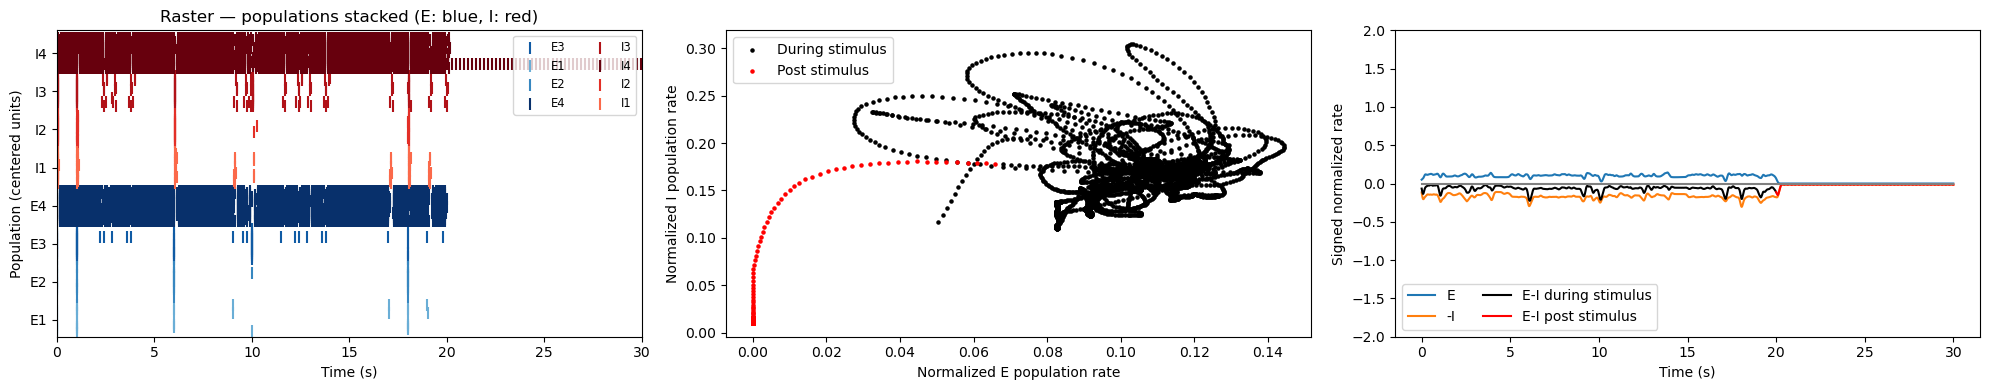

In [44]:
# =============================================================================
# 8. Plot raster and population activity
# =============================================================================

fig, (ax_raster, ax_phase, ax_rate) = plt.subplots(1, 3, figsize=(20, 4))

# -----------------------------------------------------------------------------
# Raster plot: spike times by neuron ID
# -----------------------------------------------------------------------------
"""ax_raster.scatter(e_spike_t, e_spike_id, marker='|', label='Core 0 / Excitatory')
ax_raster.scatter(i_spike_t, i_spike_id, marker='|', label='Core 2 / Inhibitory')
ax_raster.set_xlabel('Time (s)')
ax_raster.set_ylabel('Global neuron ID')
ax_raster.set_xlim(0, D)
ax_raster.set_ylim(0, 767)
ax_raster.legend()"""

# Replace raster block: stacked/pop-labelled raster drawn on `ax_raster`
ax_raster.cla()

# Build lookup (chip,core,neuron) -> (label, pop_index, unit_index)
pop_map = {}
for pidx, pop in enumerate(exc_neuron_ids):
    for uidx, (chip, core, nid) in enumerate(pop):
        pop_map[(chip, core, nid)] = ("E", pidx, uidx)
for pidx, pop in enumerate(inh_neuron_ids):
    for uidx, (chip, core, nid) in enumerate(pop):
        pop_map[(chip, core, nid)] = ("I", pidx, uidx)

# Ordered populations and stacked baseline positions
pop_order = [("E", i) for i in range(len(exc_neuron_ids))] + [("I", i) for i in range(len(inh_neuron_ids))]
base_by_pop = {}
cum = 0
gap = 3
for label, pidx in pop_order:
    size = len(exc_neuron_ids[pidx]) if label == "E" else len(inh_neuron_ids[pidx])
    base_by_pop[(label, pidx)] = cum
    cum += size + gap

# Collect spikes per population (time, y)
from collections import defaultdict
plot_bins = defaultdict(lambda: {"t": [], "y": []})
for evt in events:
    key = (evt.chip_id, evt.core_id, evt.neuron_id)
    info = pop_map.get(key)
    if info is None:
        continue
    label, pidx, uidx = info
    base = base_by_pop[(label, pidx)]
    plot_bins[(label, pidx)]["t"].append(evt.timestamp * 1e-6)
    plot_bins[(label, pidx)]["y"].append(base + uidx)

# Color maps
colors_E = plt.cm.Blues(np.linspace(0.5, 1.0, max(1, len(exc_neuron_ids))))
colors_I = plt.cm.Reds(np.linspace(0.5, 1.0, max(1, len(inh_neuron_ids))))

# Plot onto ax_raster
for (label, pidx), data in plot_bins.items():
    if not data["t"]:
        continue
    c = colors_E[pidx % len(colors_E)] if label == "E" else colors_I[pidx % len(colors_I)]
    ax_raster.scatter(data["t"], data["y"], marker="|", c=[c], s=80, label=f"{label}{pidx+1}")

# Ticks/labels/limits
yticks = []
ylabels = []
for label, pidx in pop_order:
    base = base_by_pop[(label, pidx)]
    size = len(exc_neuron_ids[pidx]) if label == "E" else len(inh_neuron_ids[pidx])
    center = base + (size - 1) / 2
    yticks.append(center)
    ylabels.append(f"{label}{pidx+1}")

ax_raster.set_yticks(yticks)
ax_raster.set_yticklabels(ylabels)
ax_raster.set_xlabel("Time (s)")
ax_raster.set_ylabel("Population (centered units)")
ax_raster.set_xlim(0, D)
ax_raster.set_ylim(-1, cum)
ax_raster.set_title("Raster — populations stacked (E: blue, I: red)")
ax_raster.legend(loc="upper right", ncol=2, fontsize="small")

# -----------------------------------------------------------------------------
# Phase-style plot: normalized E rate vs. normalized I rate
# -----------------------------------------------------------------------------
stim_end_bin = int(duration * fs)

ax_phase.scatter(
    binPOP[0, :stim_end_bin] / NE,
    binPOP[1, :stim_end_bin] / NI,
    c='k',
    s=5,
    label='During stimulus',
)
ax_phase.scatter(
    binPOP[0, stim_end_bin:] / NE,
    binPOP[1, stim_end_bin:] / NI,
    c='red',
    s=5,
    label='Post stimulus',
)
ax_phase.set_xlabel('Normalized E population rate')
ax_phase.set_ylabel('Normalized I population rate')
ax_phase.legend()

# -----------------------------------------------------------------------------
# Signed rate plot: E, -I, and E-I difference over time
# -----------------------------------------------------------------------------
time_axis = np.arange(n_bins) / fs
post_time_axis = np.arange(int(duration_post_stim * fs)) / fs + duration

ax_rate.plot(time_axis, binPOP[0] / NE, label='E')
ax_rate.plot(time_axis, -binPOP[1] / NI, label='-I')
ax_rate.plot(
    np.arange(stim_end_bin) / fs,
    binPOP[0, :stim_end_bin] / NE - binPOP[1, :stim_end_bin] / NI,
    c='k',
    label='E-I during stimulus',
)
ax_rate.plot(
    post_time_axis,
    binPOP[0, stim_end_bin:] / NE - binPOP[1, stim_end_bin:] / NI,
    c='red',
    label='E-I post stimulus',
)
ax_rate.plot([0, D], [0, 0], 'gray')
ax_rate.set_xlabel('Time (s)')
ax_rate.set_ylabel('Signed normalized rate')
ax_rate.set_ylim(-2, 2)
ax_rate.legend(loc='lower left', ncol=2)

plt.tight_layout()
# plt.savefig('EI.png')
plt.show()


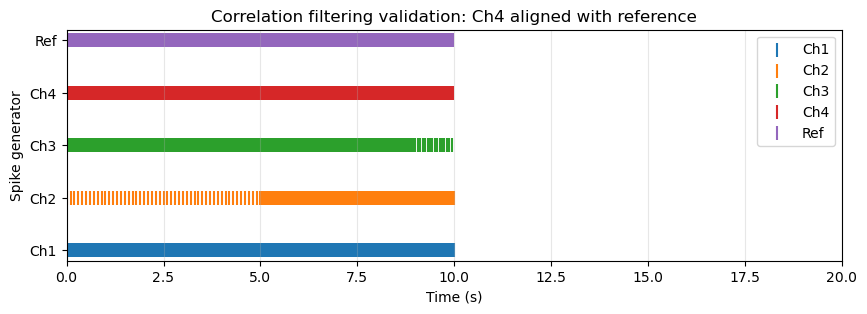

In [45]:
# =============================================================================
# Optional: plot scheduled input/reference spike trains
# =============================================================================

plt.figure(figsize=(10, 3))

y_positions = {
    "Ch1": 1,
    "Ch2": 2,
    "Ch3": 3,
    "Ch4": 4,
    "Ref": 5,
}

for name, times in input_spike_times.items():
    plt.scatter(
        times,
        np.ones_like(times) * y_positions[name],
        marker="|",
        s=100,
        label=name,
    )

plt.yticks(
    [1, 2, 3, 4, 5],
    ["Ch1", "Ch2", "Ch3", "Ch4", "Ref"],
)

plt.xlabel("Time (s)")
plt.ylabel("Spike generator")
plt.title(
    f"Correlation filtering validation: Ch{correlated_channel + 1} aligned with reference"
)
plt.xlim(0, duration)
plt.grid(True, axis="x", alpha=0.3)
plt.legend(loc="upper right")
plt.show()

In [46]:
# =============================================================================
# 9. Optional: save current hardware parameters
# =============================================================================

ut.save_parameters2txt_file(model.get_configuration(), filename='network_parameters_with_inh4.txt')
#ut.save_parameters2json_file(model.get_configuration(), filename='network_parameters_with_inh3.json')


In [47]:
# =============================================================================
# 10. Optional: reset all DYNAP-SE1 bias parameters to zero
# =============================================================================

"""from dynapse1constants import BIAS_NAMES

for chip in range(4):
    for core in range(4):
        for bias_name in BIAS_NAMES:
            zero_parameter = dyn1.Dynapse1Parameter(bias_name, 0, 0)
            model.update_single_parameter(zero_parameter, chip, core)"""


'from dynapse1constants import BIAS_NAMES\n\nfor chip in range(4):\n    for core in range(4):\n        for bias_name in BIAS_NAMES:\n            zero_parameter = dyn1.Dynapse1Parameter(bias_name, 0, 0)\n            model.update_single_parameter(zero_parameter, chip, core)'

## Parameter reference notes

The original final cell contained scratch code and unfinished debug snippets. It has been converted into notes so it will not accidentally run with undefined variables.

Useful parameter examples:

| Purpose | Parameter | Example `(coarse, fine)` |
|---|---:|---:|
| Threshold / neuron gain | `IF_THR_N` | `(6, 40)` |
| Refractory period | `IF_RFR_N` | `(3, 50)` |
| Leak / membrane time constant | `IF_TAU1_N` | `(5, 170)` |
| Secondary leak term | `IF_TAU2_N` | `(0, 0)` |
| DC current | `IF_DC_P` | `(0, 0)` |
| Fast excitatory AMPA tau | `NPDPIE_TAU_F_P` | `(4, 80)` |
| Fast excitatory AMPA threshold | `NPDPIE_THR_F_P` | `(0, 0)` |
| Fast excitatory AMPA weight | `PS_WEIGHT_EXC_F_N` | `(0, 0)` |
| Slow excitatory NMDA tau | `NPDPIE_TAU_S_P` | `(4, 80)` |
| Slow excitatory NMDA threshold | `NPDPIE_THR_S_P` | `(0, 0)` |
| Slow excitatory NMDA weight | `PS_WEIGHT_EXC_S_N` | `(0, 0)` |
| NMDA neuron parameter | `IF_NMDA_N` | `(6, 148)` |
| Fast inhibitory GABA_A tau | `NPDPII_TAU_F_P` | `(4, 80)` |

Suggested debug checks, if needed later:

```python
all_event_neuron_ids = [evt.neuron_id for evt in events]
all_event_chip_ids = [evt.chip_id for evt in events]
all_event_core_ids = [evt.core_id for evt in events]

print("All unique neuron IDs in events:", sorted(set(all_event_neuron_ids)))
print("Chips present:", sorted(set(all_event_chip_ids)))
print("Cores present:", sorted(set(all_event_core_ids)))
```
